# Challenge 2

This challenge is about OSMnx. You will explore and analyze a city's street network using the OSMnx Python library.

1. Use OSMnx to download the street network of a city of your choice. You can specify the city name, BBox or a Dict.
2. Calculate basic statistics for the street network, such as the number of nodes, edges, average node degree, etc.
3. Use OSMnx to plot the street network. Customize the plot to make it visually appealing, including node size, edge color. See the potential options here: https://osmnx.readthedocs.io/en/stable/user-reference.html#module-osmnx.plot
4. Utilize the routing capabilities of OSMnx to find the shortest path between two points in the street network. Plot the route on top of the street network.
5. Calculate the centrality measures (e.g., degree centrality and betweenness_centrality) for nodes in the street network.
6. Create the figure-groud from the selected city
7. Create interactive maps to plot nodes, edges, nodes+edges and one of the centrality measures.
8. Export the street network to a GeoPackage (.gpkg) file. Ensure that the exported file contains both node and edge attributes. Demonstrate that the new GeoPackage can be used and read in Python using any of the libraries we have seen in the class to create a simple and interactive map.
9. Finally, use OSMnx to extract other urban elements (e.g., buildings, parks) and plot them.

In [42]:
import networkx as nx
import osmnx as ox

In [51]:
#run this once
#!pip install osmnx

In [43]:
import warnings
warnings.simplefilter('ignore', DeprecationWarning)
warnings.filterwarnings('ignore')

In [44]:
#downloading our chosen street network of Carmel, Indiana, USA
# through making a query in the form of a dict
place = {"city": "Carmel", "state": "Indiana", "country": "USA"}
G = ox.graph_from_place(place, network_type="drive", truncate_by_edge=True)

In [4]:
#calculating basic statistics for the street network, such as number of nodes, edges, average node degree etc.

In [5]:
#calculating number of nodes
print("The graph has", len(G.nodes), "nodes")

#calculating number of edges
print("The graph has", len(G.edges), "edges")

The graph has 6112 nodes
The graph has 13688 edges


In [6]:
#exploring the data type of nodes
print("The nodes are", print(type(G.nodes)))

<class 'networkx.classes.reportviews.NodeView'>
The nodes are None


In [7]:
#exploring the data type of edges
print("The edges are", print(type(list(G.edges(data=True))[0])))

<class 'tuple'>
The edges are None


In [8]:
#exploring elements of the first and last nodes
print(list(G.nodes(data=True))[0])
print(list(G.nodes(data=True))[-1])

(178882025, {'y': 39.9503101, 'x': -86.2407299, 'street_count': 3})
(12706681920, {'y': 39.9995797, 'x': -86.162231, 'street_count': 2})


In [9]:
#exploring elements of the first and last edges
print(list(G.edges(data=True))[0])
print(list(G.edges(data=True))[-1])

(178882025, 178882035, {'osmid': 17263174, 'highway': 'residential', 'name': 'Tillson Drive', 'oneway': False, 'reversed': False, 'length': np.float64(388.65363766939737), 'geometry': <LINESTRING (-86.241 39.95, -86.241 39.95, -86.241 39.95, -86.241 39.95, -86...>})
(12706681920, 179782043, {'osmid': 1178222798, 'highway': 'residential', 'oneway': True, 'reversed': False, 'length': np.float64(55.36129263604355), 'geometry': <LINESTRING (-86.162 40, -86.162 40, -86.162 40, -86.162 40, -86.162 40, -86...>})


In [10]:
#calculating average node degree 
#warning - very large cell output
nx.average_neighbor_degree(G, weight="weight")

{178882025: 2.3333333333333335,
 178882035: 3.0,
 178882486: 3.0,
 178884871: 2.5,
 178888794: 2.6666666666666665,
 179688996: 3.0,
 179689026: 2.6666666666666665,
 179689126: 2.3333333333333335,
 179689162: 3.0,
 179689209: 2.5,
 179689211: 2.3333333333333335,
 179689249: 2.3333333333333335,
 179689265: 3.3333333333333335,
 179689273: 2.0,
 179689276: 4.0,
 179689283: 3.25,
 179689291: 3.0,
 179689299: 2.3333333333333335,
 179689309: 2.3333333333333335,
 179689325: 2.3333333333333335,
 179689330: 2.3333333333333335,
 179689337: 2.3333333333333335,
 179689348: 2.3333333333333335,
 179689360: 3.0,
 179689372: 3.0,
 179689393: 3.0,
 179689408: 3.0,
 179689415: 3.0,
 179689443: 3.0,
 179689601: 3.0,
 179689614: 3.3333333333333335,
 179689618: 2.3333333333333335,
 179689635: 3.0,
 179690209: 3.0,
 179690211: 3.0,
 179690254: 4.0,
 179690256: 2.3333333333333335,
 179690257: 3.0,
 179690368: 4.0,
 179690465: 2.3333333333333335,
 179690555: 2.3333333333333335,
 179690558: 3.0,
 179690585: 3.0

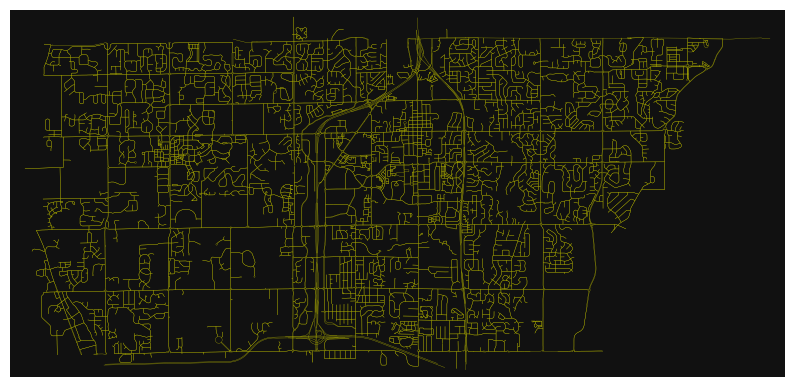

In [11]:
#plotting street network using OSMnx
fig, ax = ox.plot_graph(G, figsize=(10, 10), node_size=0, edge_color="y", edge_linewidth=0.2)

In [ ]:
#customising the node size and edge color

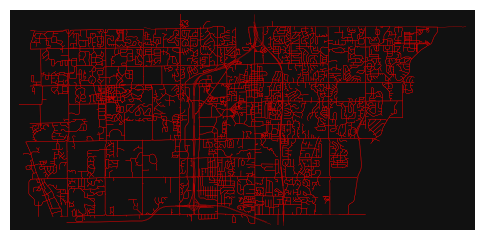

In [12]:
#first experiment, changing the color and figure size
fig, ax = ox.plot_graph(G, figsize=(6, 6), node_size=0, edge_color="r", edge_linewidth=0.2)

In [ ]:
#NOTE = this code takes extremely long to load, so run the rest of the code first then attempt to run this 
#second experiment, visualising street centrality using color - defining edge centrality and ev

#edge_centrality = nx.closeness_centrality(nx.line_graph(G))
#ev = [edge_centrality[edge + (0,)] for edge in G.edges()]

#norm = colors.Normalize(vmin=min(ev)*0.8, vmax=max(ev)) #converting the color scale to a list of colors for graph edges
#cmap = cm.ScalarMappable(norm=norm, cmap=cm.inferno)
#ec = [cmap.to_rgba(cl) for cl in ev]

# coloring the edges with closeness centralities in the line graph
#fig, ax = ox.plot_graph(G, bgcolor='k', axis_off=True, node_size=0,
                        #edge_color=ec, edge_linewidth=1.5, edge_alpha=1)

Reference: gboeing (2017). osmnx-examples/notebooks/00-osmnx-features-demo.ipynb at v0.13.0 · gboeing/osmnx-examples. [online] GitHub. Available at: https://github.com/gboeing/osmnx-examples/blob/v0.13.0/notebooks/00-osmnx-features-demo.ipynb [Accessed 16 Mar. 2025].

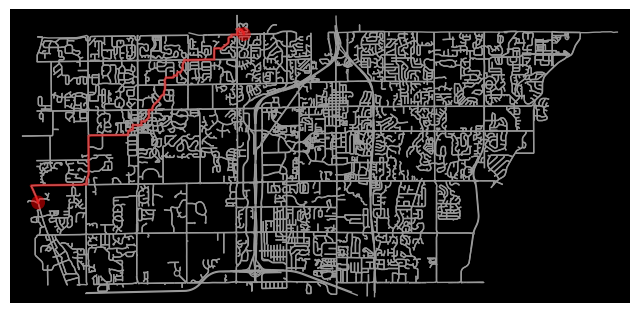

In [14]:
#utilise the routing capabilities of OSMnx to find the shortest path between two points 

#establishing origin
orig = list(G)[0]

#establishing destination
dest = list(G)[-1]

#plot the route
route = nx.shortest_path(G, orig, dest, weight='length')
fig, ax = ox.plot_graph_route(G, route, route_linewidth=2, node_size=0, bgcolor='k')

Reference: Geoff Boeing. (2016). OSMnx: Python for Street Networks. [online] Available at: https://geoffboeing.com/2016/11/osmnx-python-street-networks/.

Node 178882025: Degree Centrality =  0.001
Node 178882035: Degree Centrality =  0.000
Node 178882486: Degree Centrality =  0.000
Node 178884871: Degree Centrality =  0.001
Node 178888794: Degree Centrality =  0.001
Node 179688996: Degree Centrality =  0.001
Node 179689026: Degree Centrality =  0.001
Node 179689126: Degree Centrality =  0.001
Node 179689162: Degree Centrality =  0.000
Node 179689209: Degree Centrality =  0.001
Node 179689211: Degree Centrality =  0.001
Node 179689249: Degree Centrality =  0.001
Node 179689265: Degree Centrality =  0.001
Node 179689273: Degree Centrality =  0.001
Node 179689276: Degree Centrality =  0.000
Node 179689283: Degree Centrality =  0.001
Node 179689291: Degree Centrality =  0.001
Node 179689299: Degree Centrality =  0.001
Node 179689309: Degree Centrality =  0.001
Node 179689325: Degree Centrality =  0.001
Node 179689330: Degree Centrality =  0.001
Node 179689337: Degree Centrality =  0.001
Node 179689348: Degree Centrality =  0.001
Node 179689

NameError: name 'plt' is not defined

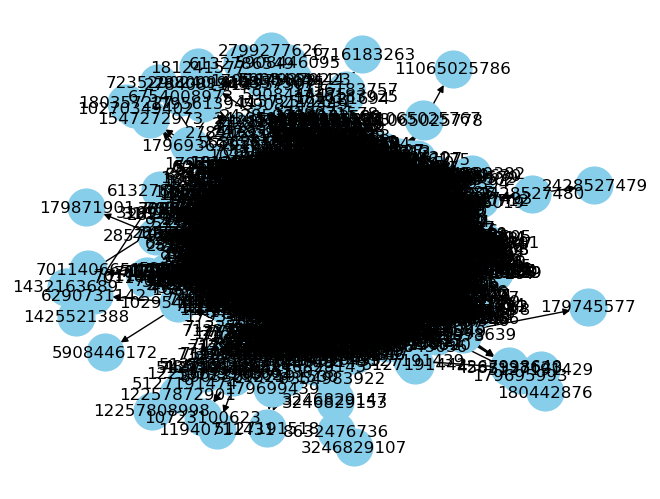

In [15]:
#calculating centrality measures
#calculating degree centrality
degree_centrality = nx.degree_centrality(G)
for node, centrality in degree_centrality.items():
    print(f"Node {node}: Degree Centrality = {centrality: .3f}")
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=700, node_color='skyblue')
plt.title('Graph G with Degree Centrality')
plt.show()

#calculating betweenness centrality
extended_stats = ox.extended_stats(G, bc=True)
print(extended_stats['betweenness_centrality_avg'])

In [18]:
#creating figure-ground diagram from San Diego
import osmnx as ox
from IPython.display import Image

In [19]:
#configuring the inline image display
img_folder = "images"
extension = "png"
size = 240
dpi = 40

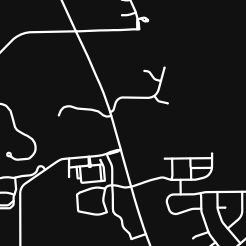

In [38]:
#picking a point in Carmel to display
place = 'Carmel'
point=(39.9503101, -86.2407299)
fp = f"./{img_folder}/{place}.{extension}"

G = ox.graph_from_point(point, dist=1000, network_type='drive')

fig, ax = ox.plot_figure_ground(
    G,
    filepath=fp,
    dpi=dpi,
    save=True,
    show=False,
    close=True,
)
Image(fp, height=size, width=size)

Reference: gboeing (2017). osmnx-examples/notebooks/09-example-figure-ground.ipynb at v0.11 · gboeing/osmnx-examples. [online] GitHub. Available at: https://github.com/gboeing/osmnx-examples/blob/v0.11/notebooks/09-example-figure-ground.ipynb [Accessed 16 Mar. 2025].

In [24]:
#creating interactive maps to plot nodes, edges, nodes+edges and one of centrality measures

In [28]:
# exploring graph edges interactively, with a simple one-liner
ox.graph_to_gdfs(G, nodes=False).explore()

In [29]:
# exploring graph nodes interactively, with different basemap tiles
nodes = ox.graph_to_gdfs(G, edges=False)
nodes.explore(tiles="cartodbpositron", marker_kwds={"radius": 8})

In [30]:
# exploring nodes and edges together in a single map
nodes, edges = ox.graph_to_gdfs(G)
m = edges.explore(color="skyblue", tiles="cartodbdarkmatter")
nodes.explore(m=m, color="pink", marker_kwds={"radius": 6})

In [31]:
# exploring graph edges interactively, colored by length
edges.explore(tiles="cartodbdarkmatter", column="length", cmap="plasma")

In [32]:
# exploring graph nodes interactively, colored by betweenness centrality
nx.set_node_attributes(G, nx.betweenness_centrality(G, weight="length"), name="bc")
nodes = ox.graph_to_gdfs(G, edges=False)
nodes.explore(tiles="cartodbdarkmatter", column="bc", marker_kwds={"radius": 8})

In [47]:
#exporting street network to a geopackage file
ox.save_graph_geopackage(G, filepath="./data/mynetwork.gpkg")
ox.save_graphml(G, filepath="./data/mynetwork.graphml")

In [48]:
#reading the geopackage file in python
read = "./data/mynetwork.gpkg"

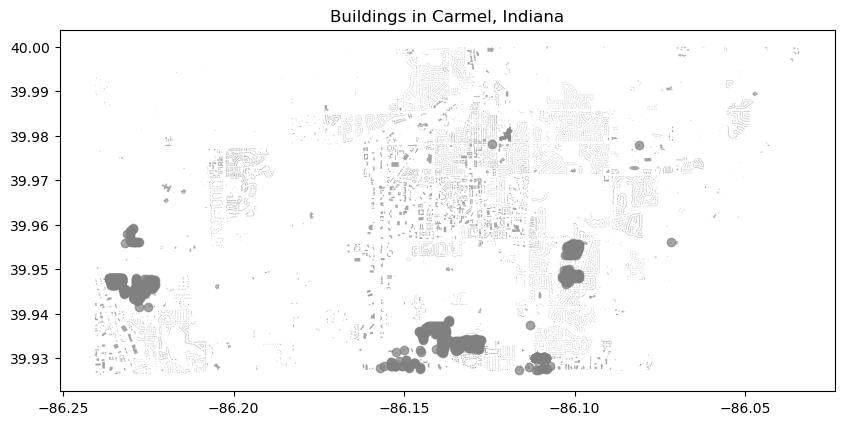

In [53]:
#using OSMnx to extract other urban elements e.g. buildings, parks and plotting them
import matplotlib.pyplot as plt

place_name = "Carmel, Indiana, USA"
buildings = ox.features_from_place(place_name, tags={"building": True})
fig, ax = plt.subplots(figsize=(10, 10))
buildings.plot(ax=ax, color="gray", alpha=0.7)
plt.title("Buildings in Carmel, Indiana")
plt.show()

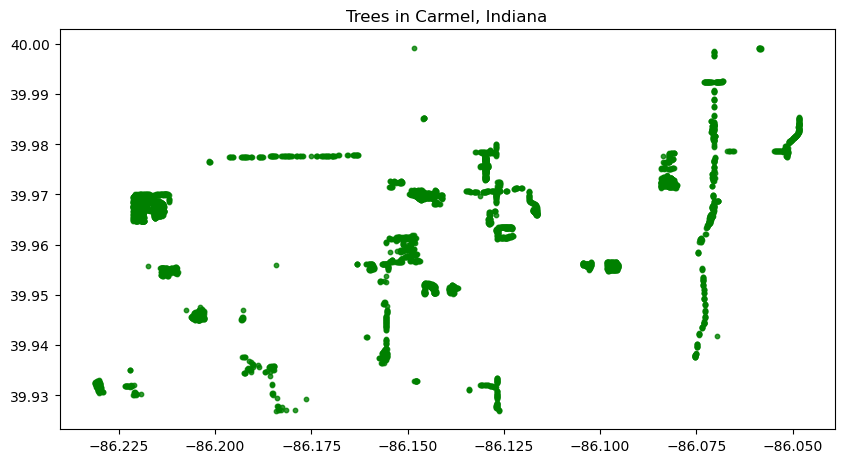

In [54]:
trees = ox.features_from_place(place_name, tags={"natural": "tree"})

fig, ax = plt.subplots(figsize=(10, 10))
trees.plot(ax=ax, color="green", markersize=10, alpha=0.8)
plt.title("Trees in Carmel, Indiana")
plt.show()

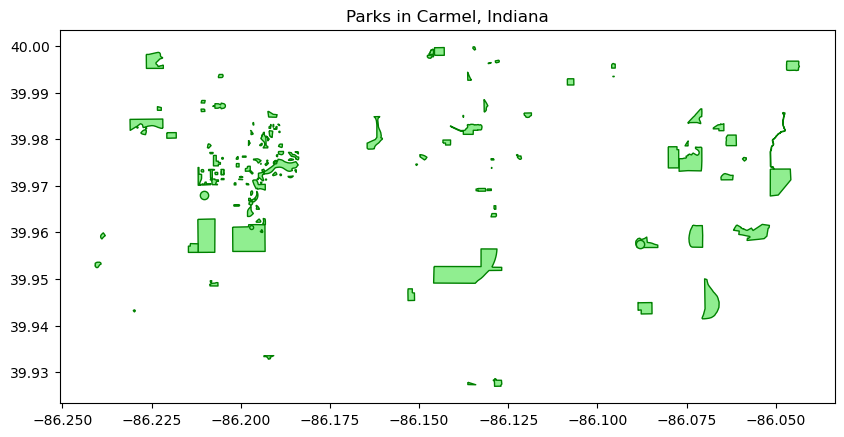

In [55]:
parks = ox.features_from_place(place_name, tags={"leisure": "park"})

fig, ax = plt.subplots(figsize=(10, 10))
parks.plot(ax=ax, color="lightgreen", edgecolor="green", linewidth=1)
plt.title("Parks in Carmel, Indiana")
plt.show()